# Method Comparison

Both methods produce bitmaps where the oddball looks similar to the distractors. They differ in *what* is actually different.

| | Method 1 — Hue Shift | Method 2 — Shifted Mean |
|---|---|---|
| Colors used | Distractor and oddball have **different colors** — the palette is shifted slightly in hue space | Distractor and oddball use the **exact same colors** |
| What changes | The whole color distribution is displaced in color space | The mean of the proportion distribution over the shared palette |
| Technically | Different sets of colors, close in hue | Same colors, different proportions |

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from skimage.color import lab2rgb, rgb2lab

BITMAP_SIZE = 300
TILE_GRID   = 20
SEED        = 42
print('imports ok')

## Shared utilities

In [ ]:
def lab_palette_colors(L, a, b, n_shades):
    C = np.sqrt(a**2 + b**2)
    offsets = np.arange(n_shades) - (n_shades - 1) / 2.0
    lab = np.stack([
        np.full(n_shades, L),
        a + offsets * (-b / C),
        b + offsets * (a / C),
    ], axis=1)
    rgb = np.clip(lab2rgb(lab.reshape(1, -1, 3))[0], 0, 1)
    return np.round(rgb * 255).astype(np.uint8)


def rotate_ab(a, b, de):
    """Rotate (a*, b*) by de ΔE around the origin."""
    C = np.sqrt(a**2 + b**2)
    deg = np.degrees(2 * np.arcsin(np.clip(de / (2 * C), 0, 1)))
    h = np.arctan2(b, a) + np.deg2rad(deg)
    return C * np.cos(h), C * np.sin(h)


def generate_bitmap(colors_rgb, proportions, rng, size=BITMAP_SIZE, tile_grid=TILE_GRID):
    cell_size   = size // tile_grid
    out_size    = cell_size * tile_grid
    total_cells = tile_grid * tile_grid
    counts = np.round(proportions * total_cells).astype(int)
    counts = np.maximum(counts, 0)
    counts[np.argmax(counts)] += total_cells - counts.sum()
    cell_colors = np.repeat(np.arange(len(colors_rgb)), counts)
    rng.shuffle(cell_colors)
    bmp = np.zeros((out_size, out_size, 3), dtype=np.uint8)
    for idx, ci in enumerate(cell_colors):
        row, col = divmod(idx, tile_grid)
        y0, x0 = row * cell_size, col * cell_size
        bmp[y0:y0 + cell_size, x0:x0 + cell_size] = colors_rgb[ci]
    return bmp


print('utilities ok')

## Method 1 — Hue Shift

The distractor and oddball palettes are anchored at **different points in hue space**.
Both palettes have the same spread and number of shades, but they cover a slightly different region of the color wheel.
The shift is small (`oddball_de`), so the bitmaps look similar — but the oddball is technically a different set of colors.

In [ ]:
def m1_colors(L, a, b, n_shades, oddball_de):
    """
    Returns (dist_colors, odd_colors).
    Distractor anchor: (a, b).
    Oddball anchor: rotated by oddball_de ΔE in hue space.
    """
    dist_colors = lab_palette_colors(L, a, b, n_shades)
    a_odd, b_odd = rotate_ab(a, b, oddball_de)
    odd_colors   = lab_palette_colors(L, a_odd, b_odd, n_shades)
    return dist_colors, odd_colors

## Method 2 — Shifted Mean

Distractor and oddball share **exactly the same palette**.
The difference is in how much of each color appears: both use a Gaussian-weighted distribution, but the oddball's peak is shifted by `mean_shift` steps along the palette.
Every color is present in both — only the proportions differ.

In [ ]:
def m2_proportions(n_colors, mean_shift, sigma):
    """
    Returns (dist_props, odd_props) over a shared palette of n_colors.
    Distractor: Gaussian peaked at palette center.
    Oddball:    Gaussian peaked at center + mean_shift.
    A uniform floor keeps all colors non-zero.
    """
    indices  = np.arange(n_colors, dtype=float)
    midpoint = (n_colors - 1) / 2.0
    floor    = np.ones(n_colors) / n_colors

    def gauss(mean):
        g = np.exp(-0.5 * ((indices - mean) / sigma) ** 2)
        g /= g.sum()
        w = 0.5 * floor + 0.5 * g
        return w / w.sum()

    return gauss(midpoint), gauss(midpoint + mean_shift)

## Comparison grid

In [ ]:
def compare(L, a, b,
            n_shades=12,
            oddball_de=4,            # Method 1: hue shift 
            mean_shift=3, sigma=4,   # Method 2: proportion mean shift
            tile_grid=TILE_GRID,
            seed=SEED):

    flat = np.ones(n_shades) / n_shades

    # Method 1
    dist_colors, odd_colors = m1_colors(L, a, b, n_shades, oddball_de)
    bm1 = ([generate_bitmap(odd_colors,  flat, np.random.RandomState(seed), tile_grid=tile_grid)] +
           [generate_bitmap(dist_colors, flat, np.random.RandomState(seed + i + 1), tile_grid=tile_grid)
            for i in range(3)])

    # Method 2
    shared_colors = lab_palette_colors(L, a, b, n_shades)
    d2_props, o2_props = m2_proportions(n_shades, mean_shift, sigma)
    bm2 = ([generate_bitmap(shared_colors, o2_props, np.random.RandomState(seed), tile_grid=tile_grid)] +
           [generate_bitmap(shared_colors, d2_props, np.random.RandomState(seed + i + 1), tile_grid=tile_grid)
            for i in range(3)])

    # ── Figure ───────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(17, 9))
    fig.suptitle(f'L={L}, a={a}, b={b}  |  {n_shades} shades  |  grid={tile_grid}×{tile_grid}',
                 fontsize=12, fontweight='bold')

    gs = fig.add_gridspec(2, 7,
                          width_ratios=[0.08, 1.2, 1.2, 1.5, 1.5, 1.5, 1.5],
                          hspace=0.35, wspace=0.06,
                          left=0.04, right=0.99, top=0.88, bottom=0.04)

    def draw_palette(ax, colors, title):
        for i, c in enumerate(colors.astype(float) / 255):
            ax.add_patch(patches.Rectangle((i, 0), 1, 1, color=c))
        ax.set_xlim(0, len(colors))
        ax.set_ylim(0, 1)
        ax.axis('off')
        ax.set_title(title, fontsize=8)

    def draw_bitmap(ax, bm, label):
        ax.imshow(bm)
        ax.set_title(label, fontsize=8)
        ax.axis('off')
        if label == 'ODDBALL':
            for sp in ax.spines.values():
                sp.set_edgecolor('crimson')
                sp.set_linewidth(2.5)

    labels = ['ODDBALL', 'distractor 1', 'distractor 2', 'distractor 3']

    # ── Method 1 (row 0) ─────────────────────────────────────────────────────
    ax_lbl = fig.add_subplot(gs[0, 0])
    ax_lbl.axis('off')
    ax_lbl.text(0.5, 0.5, f'Method 1\nHue Shift\noddball ΔE={oddball_de}',
                fontsize=8, ha='center', va='center',
                transform=ax_lbl.transAxes, rotation=90)

    draw_palette(fig.add_subplot(gs[0, 1]), dist_colors, 'Distractor palette')
    draw_palette(fig.add_subplot(gs[0, 2]), odd_colors,
                 f'Oddball palette\n(shifted {oddball_de} ΔE in hue space)')

    for col_i, (bm, lbl) in enumerate(zip(bm1, labels)):
        draw_bitmap(fig.add_subplot(gs[0, col_i + 3]), bm, lbl)

    # ── Method 2 (row 1) ─────────────────────────────────────────────────────
    ax_lbl2 = fig.add_subplot(gs[1, 0])
    ax_lbl2.axis('off')
    ax_lbl2.text(0.5, 0.5, f'Method 2\nShifted Mean\nshift={mean_shift}, σ={sigma}',
                 fontsize=8, ha='center', va='center',
                 transform=ax_lbl2.transAxes, rotation=90)

    ax_shared = fig.add_subplot(gs[1, 1:3])
    for i, c in enumerate(shared_colors.astype(float) / 255):
        ax_shared.add_patch(patches.Rectangle((i, 0), 1, 0.38, color=c))
    x = np.arange(n_shades)
    ax_shared.bar(x + 0.5, d2_props / d2_props.max() * 0.55,
                  bottom=0.42, color='steelblue', alpha=0.75, width=0.9, label='distractor')
    ax_shared.bar(x + 0.5, o2_props / o2_props.max() * 0.55,
                  bottom=0.42, color='tomato', alpha=0.75, width=0.9, label='oddball')
    ax_shared.set_xlim(0, n_shades)
    ax_shared.set_ylim(0, 1.05)
    ax_shared.axis('off')
    ax_shared.legend(fontsize=7, loc='upper right', framealpha=0.6)
    ax_shared.set_title('Shared palette + proportion distributions', fontsize=8)

    for col_i, (bm, lbl) in enumerate(zip(bm2, labels)):
        draw_bitmap(fig.add_subplot(gs[1, col_i + 3]), bm, lbl)

    plt.show()

In [ ]:
compare(L=60, a=70,  b=-60)   # red-pink

In [ ]:
compare(L=60, a=-80, b=-20)   # teal

In [ ]:
compare(L=60, a=60,  b=80)    # yellow-green

## Within-category examples: blue and purple

Anchors chosen to sit near the center of each color category, so small hue shifts stay within the same perceptual category.

In [ ]:
# Blue — anchored at a*=0, b*=-70 (center of blue category)
compare(L=55, a=0, b=-70)

In [ ]:
compare(L=55, a=45, b=-60, oddball_de=7, tile_grid=12, mean_shift=-8)
compare(L=55, a=45, b=-60, oddball_de=7, tile_grid=12, mean_shift= 8)
compare(L=55, a=45, b=-60, oddball_de=2, tile_grid=12, mean_shift= 2)

## Try different difficulty levels

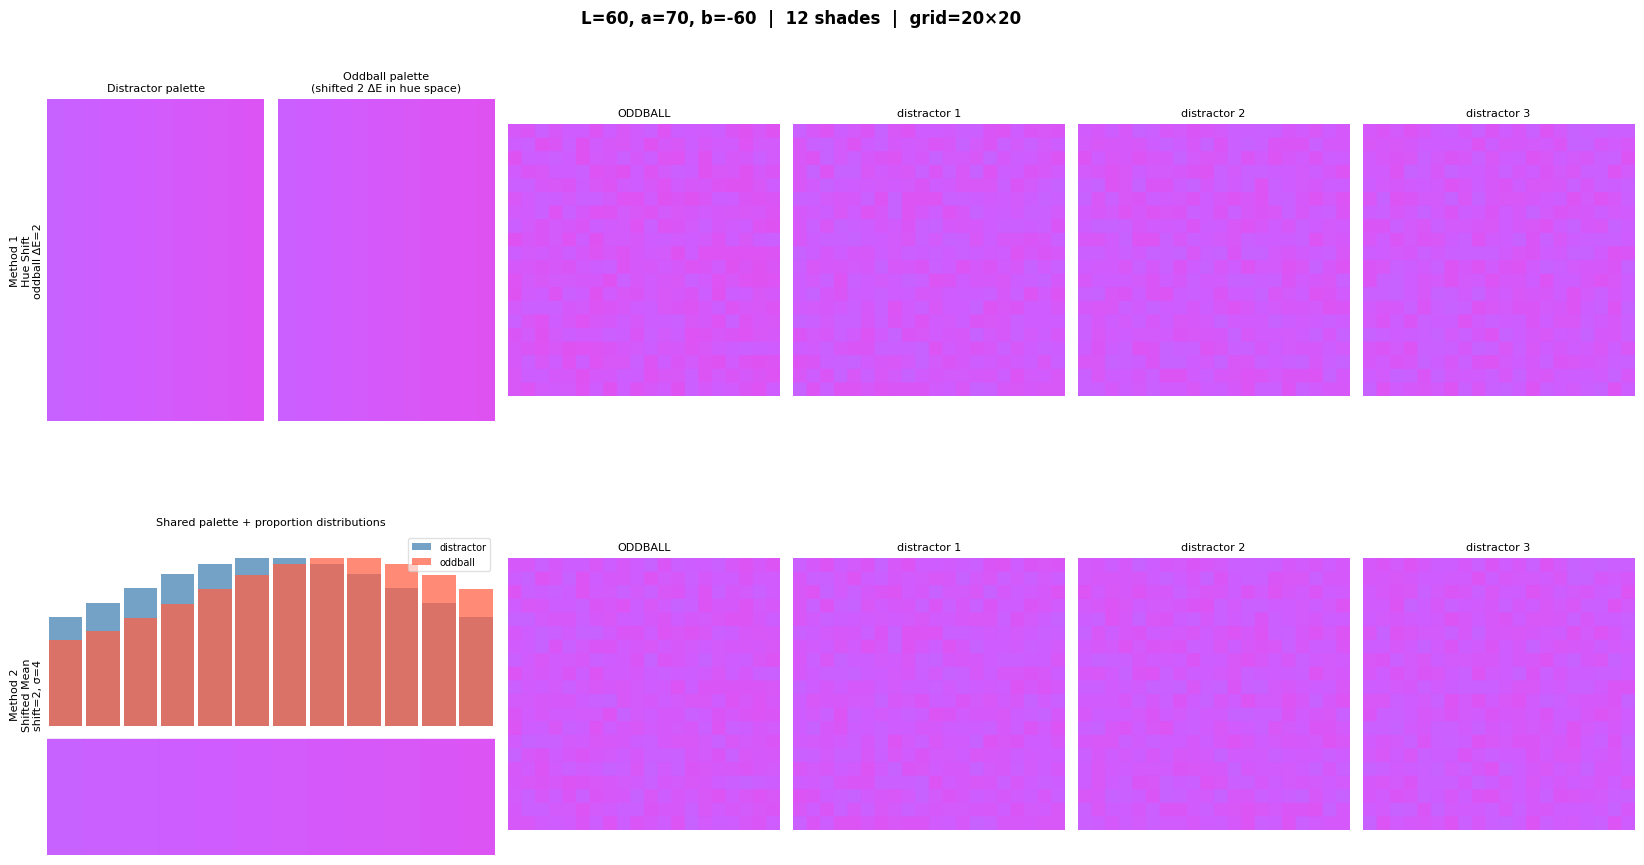

In [45]:
# Smaller shift = harder
compare(L=60, a=70, b=-60, oddball_de=2, mean_shift=2)

In [ ]:
# Larger shift = easier
compare(L=60, a=80, b=-60, oddball_de=8, mean_shift=6)

## 12×12 grid (larger squares) - showcasing when the color ensemble percept breaks down

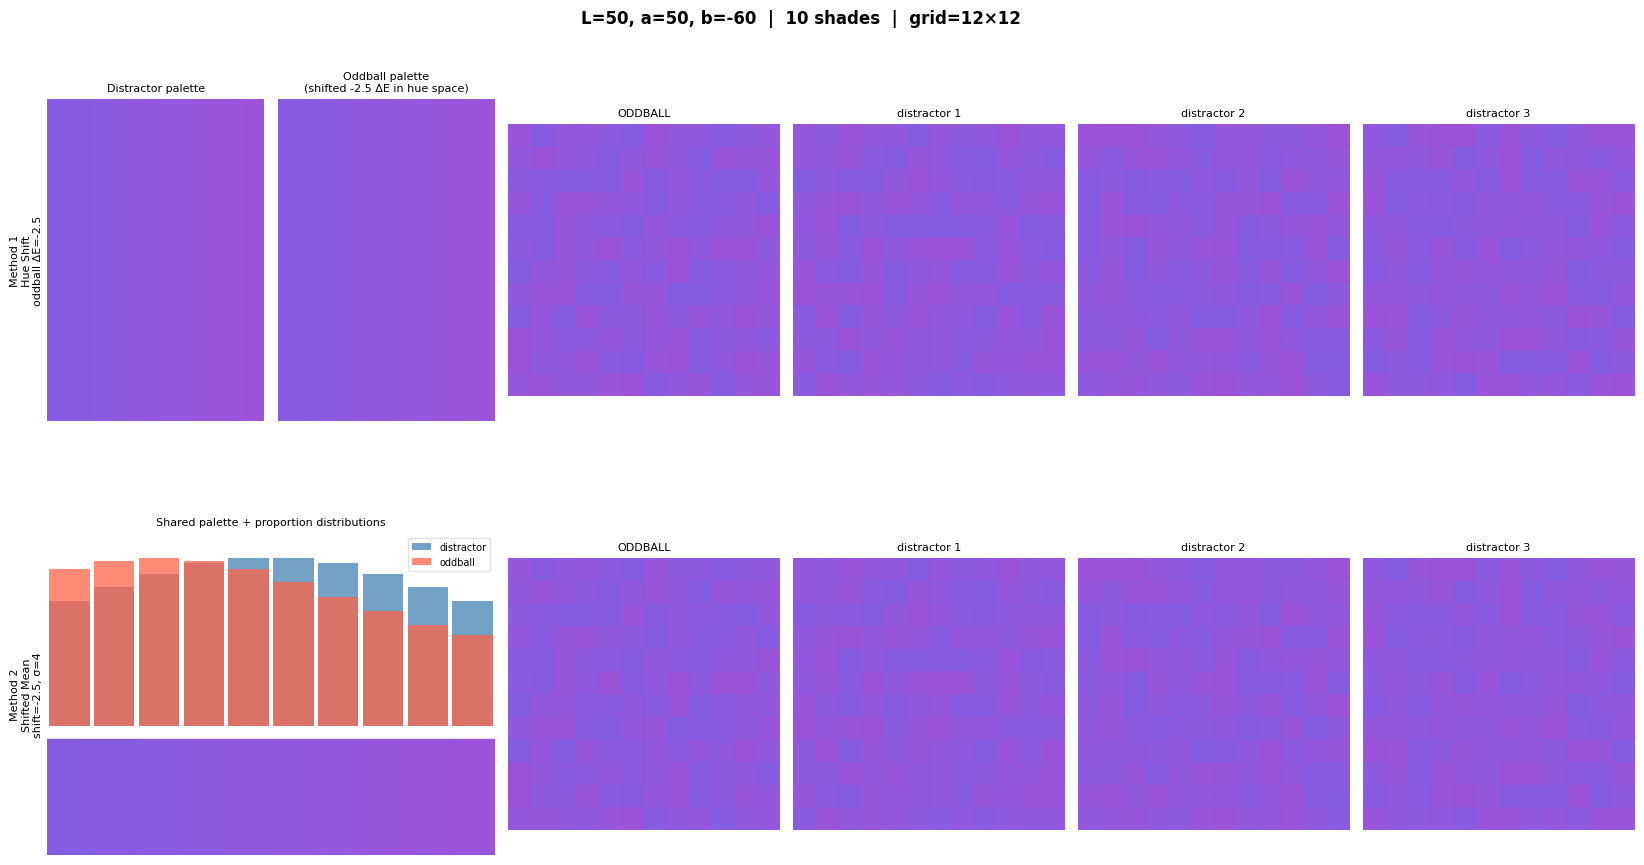

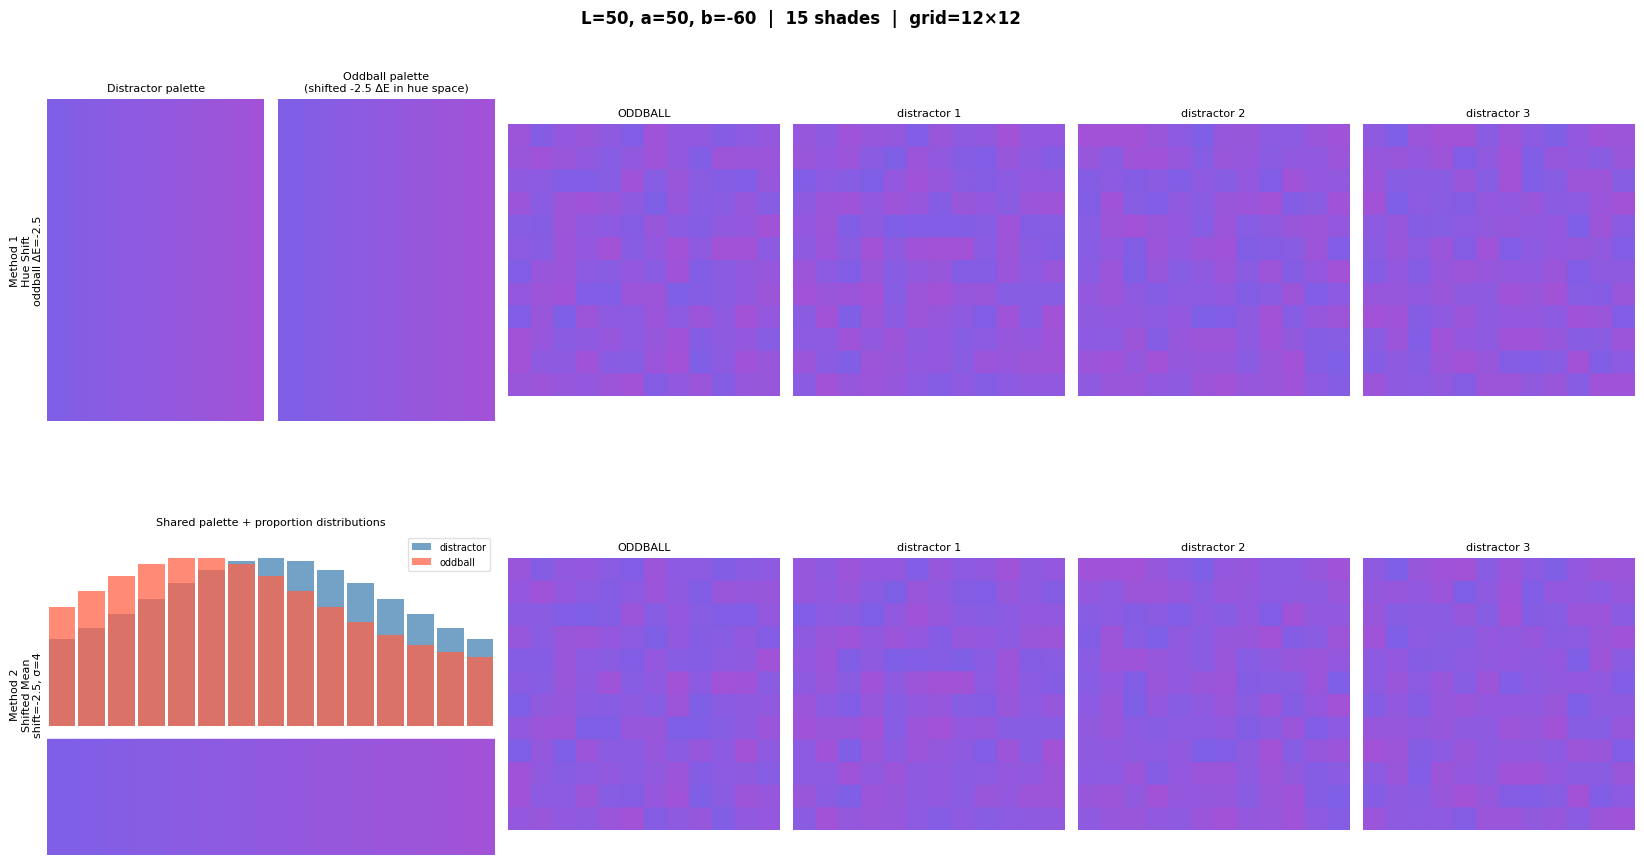

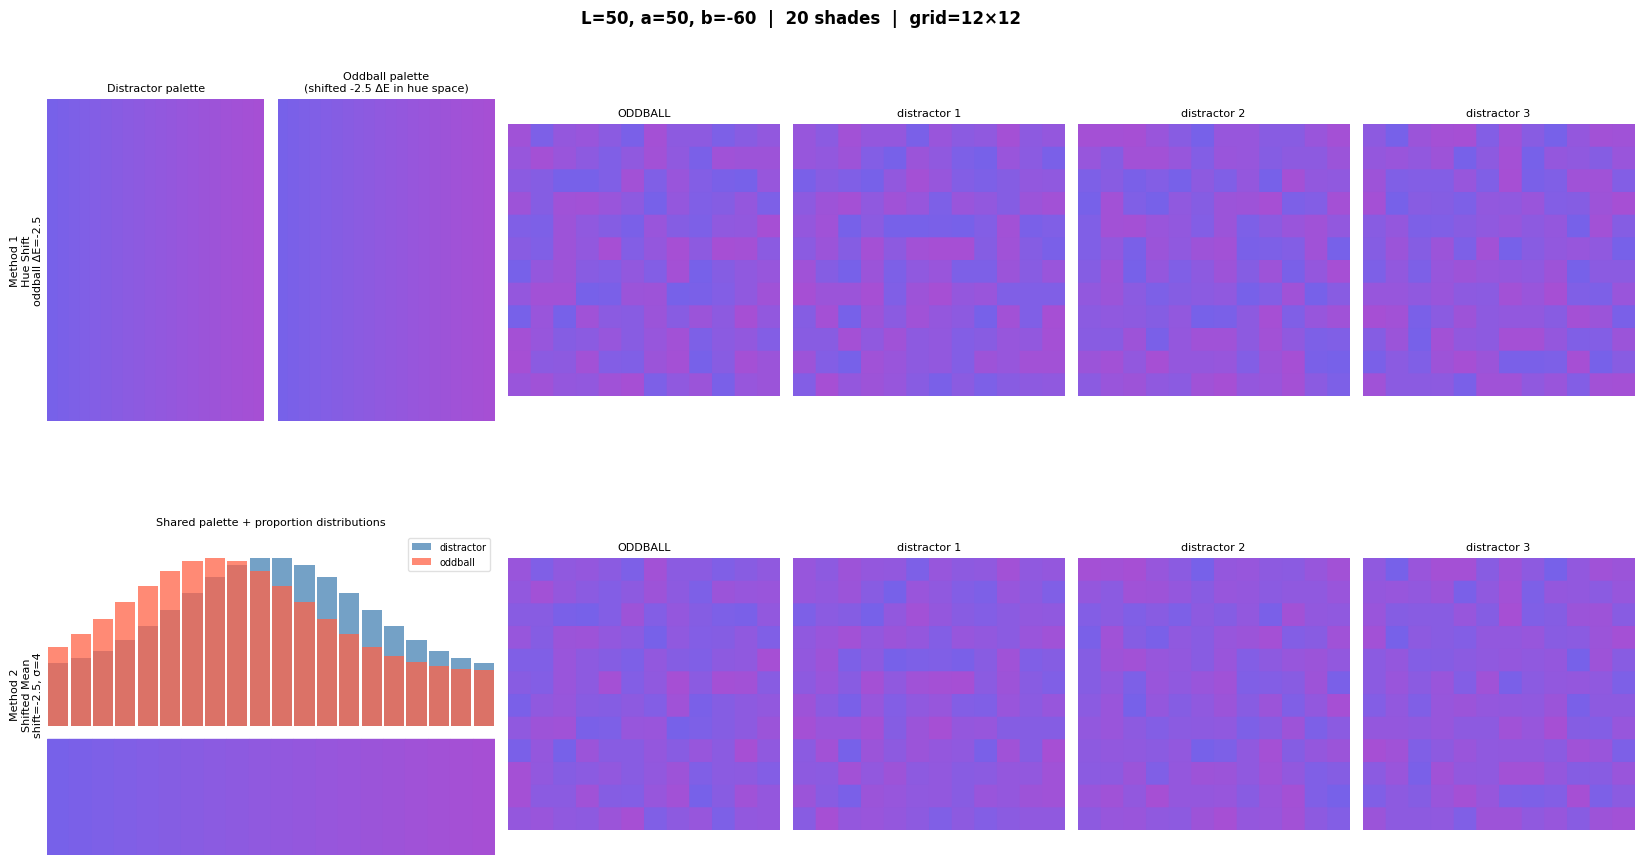

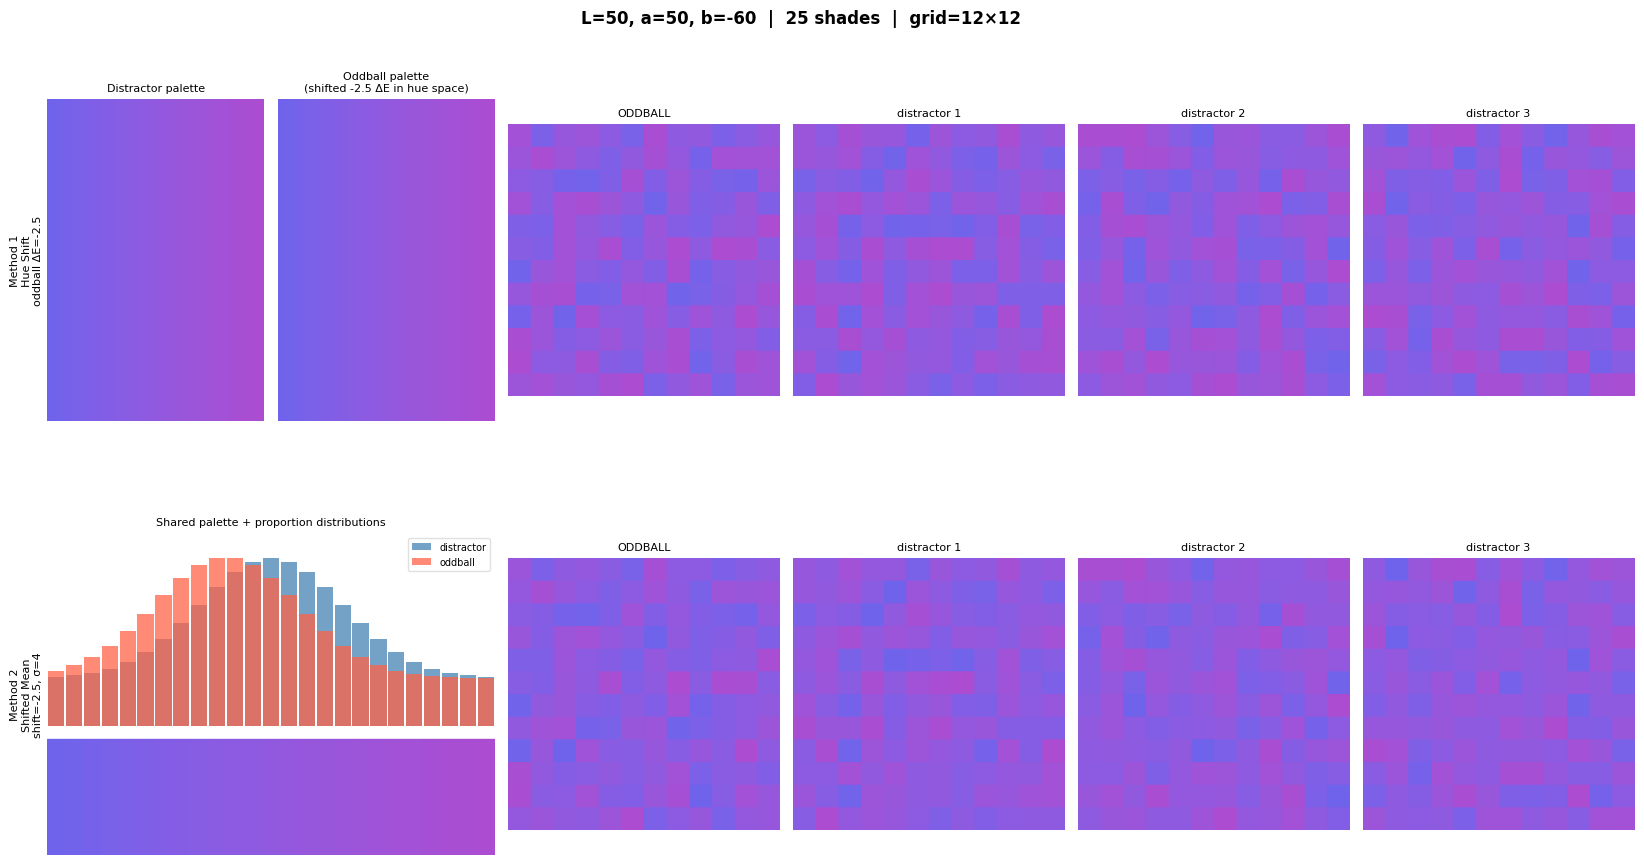

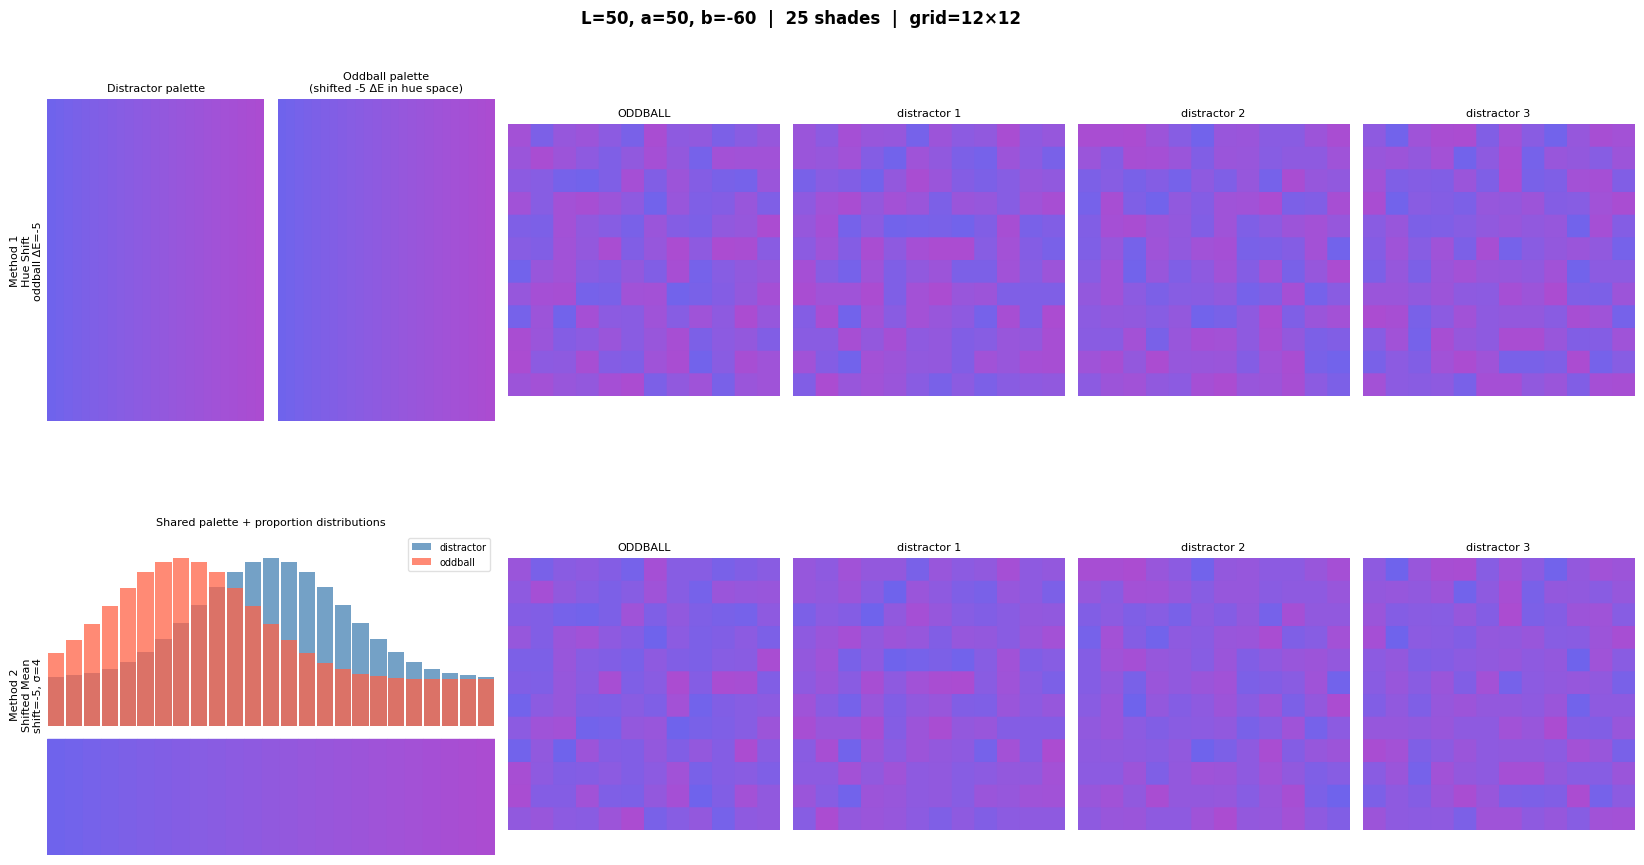

In [46]:
compare(L=50, a=50,  b=-60, tile_grid=12, n_shades=10, oddball_de=-2.5, mean_shift=-2.5)   # purple
compare(L=50, a=50,  b=-60, tile_grid=12, n_shades=15, oddball_de=-2.5, mean_shift=-2.5)   # purple
compare(L=50, a=50,  b=-60, tile_grid=12, n_shades=20, oddball_de=-2.5, mean_shift=-2.5)   # purple
compare(L=50, a=50,  b=-60, tile_grid=12, n_shades=25, oddball_de=-2.5, mean_shift=-2.5)   # purple
compare(L=50, a=50,  b=-60, tile_grid=12, n_shades=25, oddball_de=-5, mean_shift=-5)   # purple



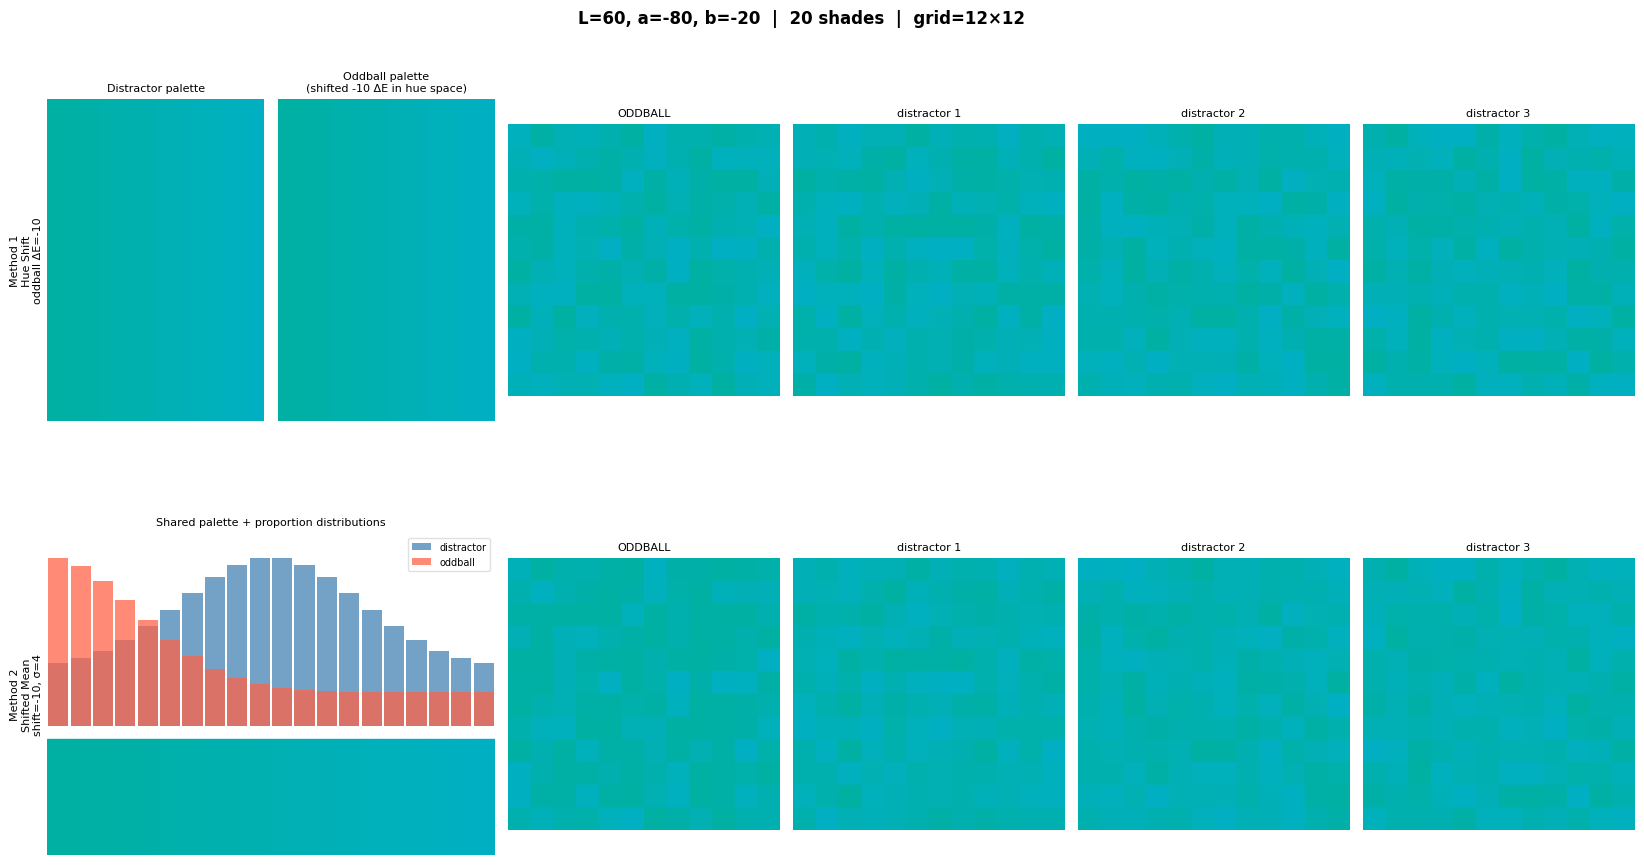

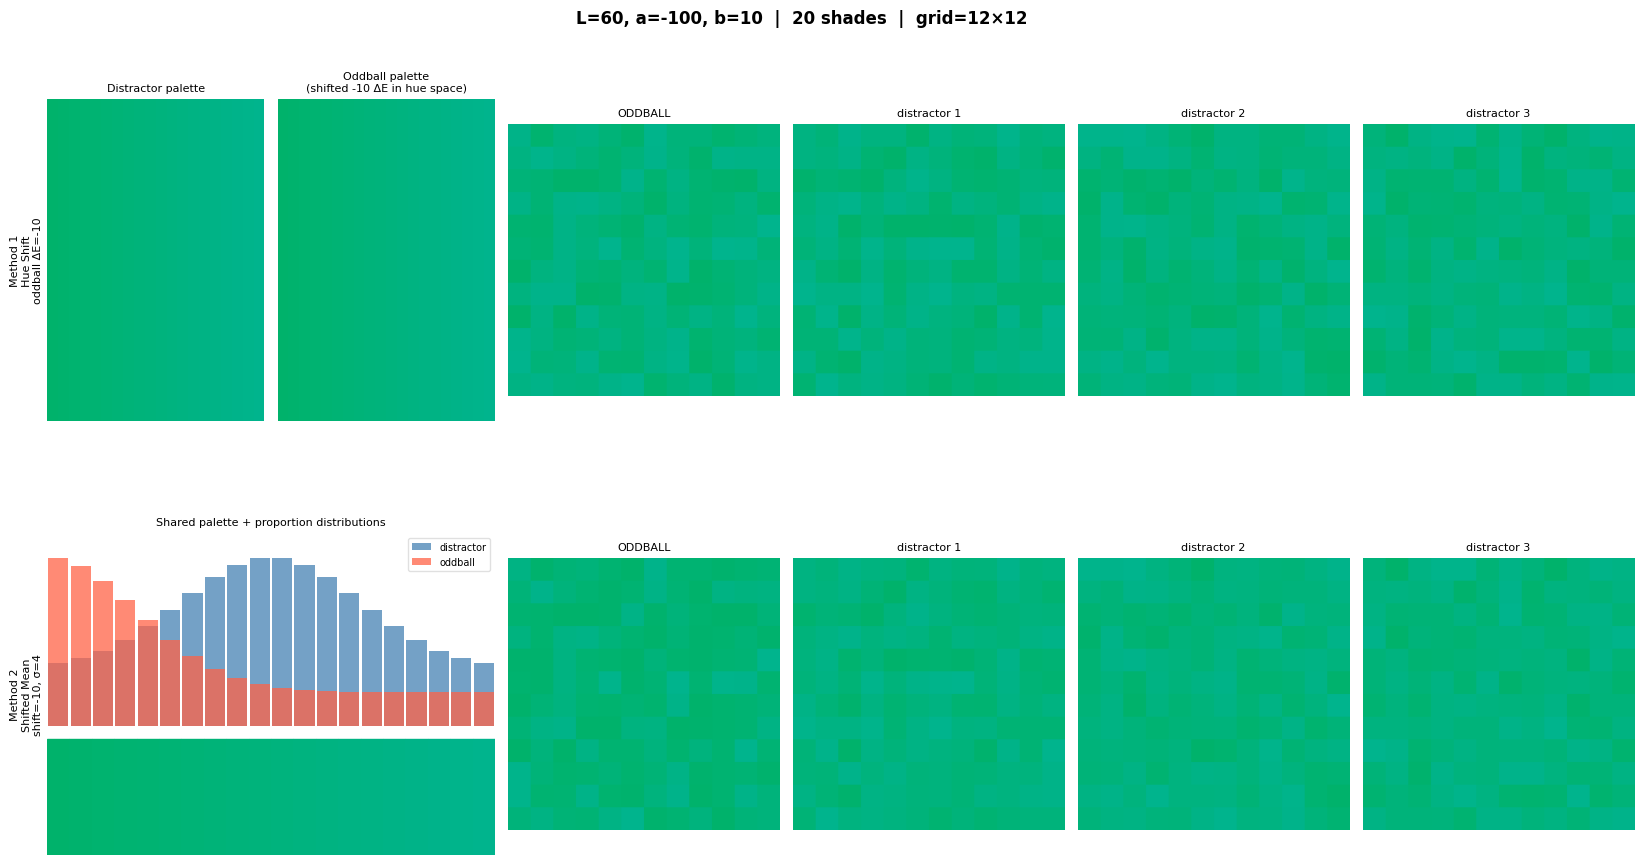

In [44]:
compare(L=60, a=-80, b=-20, tile_grid = 12,n_shades=20, oddball_de=-10, mean_shift=-10)   # teal
compare(L=60, a=-100, b=10, tile_grid = 12, oddball_de=-10, mean_shift=-10, n_shades=20)   # green